# Part 2: Data Exploration & Business Insights
## SkyGeni Sales Intelligence Analysis

**Objective:** Identify actionable insights and custom metrics to help the CRO understand the win rate decline.

**Analysis Approach:** Each insight is analyzed for:
1. **Full Dataset** (2023-2024)
2. **Last Two Quarters** (Q1 + Q2 2024) - The period of concern

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

# Load and prepare data
df = pd.read_csv('skygeni_sales_data.csv')
df['created_date'] = pd.to_datetime(df['created_date'])
df['closed_date'] = pd.to_datetime(df['closed_date'])
df['closed_quarter'] = df['closed_date'].dt.to_period('Q')
df['is_won'] = (df['outcome'] == 'Won').astype(int)

# Create filtered dataset for last two quarters
df_l2q = df[df['closed_quarter'].isin([pd.Period('2024Q1'), pd.Period('2024Q2')])].copy()

print(f"Full Dataset: {len(df):,} deals | Win Rate: {df['is_won'].mean()*100:.1f}%")
print(f"Last 2 Quarters: {len(df_l2q):,} deals | Win Rate: {df_l2q['is_won'].mean()*100:.1f}%")

Full Dataset: 5,000 deals | Win Rate: 45.3%
Last 2 Quarters: 1,627 deals | Win Rate: 45.5%


---
# 🔧 Custom Metrics (2 Novel Metrics)

Beyond standard metrics like win rate, we introduce two custom metrics designed for actionable insights.

## Custom Metric 1: Deal Velocity Score (DVS)

**Definition:** Measures how efficiently deals convert relative to their size.

$$DVS = \frac{Deal\ Amount}{Sales\ Cycle\ Days} \times Win\ Rate$$

**Why it matters:** A high DVS means fast-closing, high-value wins - the ideal outcome. Low DVS indicates either slow cycles, low values, or poor win rates.

**Action it drives:** Focus resources on segments/reps with high DVS to maximize revenue velocity.

In [2]:
def calculate_dvs(data, group_col):
    """Calculate Deal Velocity Score by segment"""
    result = data.groupby(group_col).agg(
        avg_deal_value=('deal_amount', 'mean'),
        avg_cycle=('sales_cycle_days', 'mean'),
        win_rate=('is_won', 'mean'),
        total_deals=('deal_id', 'count')
    ).reset_index()
    result['DVS'] = (result['avg_deal_value'] / result['avg_cycle']) * result['win_rate']
    return result.sort_values('DVS', ascending=False)

print("=" * 70)
print("CUSTOM METRIC 1: DEAL VELOCITY SCORE (DVS) BY INDUSTRY")
print("=" * 70)

print("\n📊 FULL DATASET:")
dvs_full = calculate_dvs(df, 'industry')
print(dvs_full[['industry', 'avg_deal_value', 'avg_cycle', 'win_rate', 'DVS']].round(1).to_string(index=False))

print("\n📊 LAST TWO QUARTERS (Q1+Q2 2024):")
dvs_l2q = calculate_dvs(df_l2q, 'industry')
print(dvs_l2q[['industry', 'avg_deal_value', 'avg_cycle', 'win_rate', 'DVS']].round(1).to_string(index=False))

CUSTOM METRIC 1: DEAL VELOCITY SCORE (DVS) BY INDUSTRY

📊 FULL DATASET:
  industry  avg_deal_value  avg_cycle  win_rate    DVS
   FinTech        25759.70      63.90      0.50 192.40
    EdTech        27346.70      62.90      0.40 192.00
 Ecommerce        26626.40      63.90      0.40 187.10
      SaaS        26502.00      64.60      0.50 185.20
HealthTech        25163.60      63.50      0.40 176.70

📊 LAST TWO QUARTERS (Q1+Q2 2024):
  industry  avg_deal_value  avg_cycle  win_rate    DVS
   FinTech        27395.10      68.70      0.50 191.90
      SaaS        27474.10      70.00      0.50 179.50
    EdTech        28664.20      72.50      0.40 168.00
HealthTech        25365.90      70.90      0.50 164.10
 Ecommerce        24505.20      68.40      0.50 163.70


## Custom Metric 2: Rep Consistency Index (RCI)

**Definition:** Measures how consistent a rep's performance is across different segments.

$$RCI = 1 - \frac{Std\ Dev\ of\ Win\ Rates\ Across\ Segments}{Mean\ Win\ Rate}$$

**Why it matters:** A rep with high overall win rate but low RCI may only perform well in specific niches. High RCI = reliable across all situations.

**Action it drives:** Identify versatile reps for complex deals; specialists for niche segments.

In [3]:
def calculate_rci(data):
    """Calculate Rep Consistency Index"""
    # Win rate by rep and industry
    rep_industry = data.groupby(['sales_rep_id', 'industry'])['is_won'].agg(['mean', 'count']).reset_index()
    rep_industry = rep_industry[rep_industry['count'] >= 5]  # Min 5 deals
    
    # Calculate consistency
    rci = rep_industry.groupby('sales_rep_id').agg(
        mean_wr=('mean', 'mean'),
        std_wr=('mean', 'std'),
        segments=('industry', 'count')
    ).reset_index()
    
    rci['RCI'] = 1 - (rci['std_wr'].fillna(0) / rci['mean_wr'].clip(lower=0.01))
    rci['RCI'] = rci['RCI'].clip(0, 1)
    
    # Add overall win rate
    overall = data.groupby('sales_rep_id')['is_won'].agg(['mean', 'count']).reset_index()
    overall.columns = ['sales_rep_id', 'overall_wr', 'total_deals']
    
    return rci.merge(overall, on='sales_rep_id').sort_values('RCI', ascending=False)

print("=" * 70)
print("CUSTOM METRIC 2: REP CONSISTENCY INDEX (RCI)")
print("=" * 70)

print("\n📊 FULL DATASET - Top 5 Most Consistent Reps:")
rci_full = calculate_rci(df)
print(rci_full[['sales_rep_id', 'overall_wr', 'RCI', 'segments', 'total_deals']].head().round(2).to_string(index=False))

print("\n📊 LAST TWO QUARTERS - Top 5 Most Consistent Reps:")
rci_l2q = calculate_rci(df_l2q)
print(rci_l2q[['sales_rep_id', 'overall_wr', 'RCI', 'segments', 'total_deals']].head().round(2).to_string(index=False))

CUSTOM METRIC 2: REP CONSISTENCY INDEX (RCI)

📊 FULL DATASET - Top 5 Most Consistent Reps:
sales_rep_id  overall_wr  RCI  segments  total_deals
       rep_1        0.45 0.92         5          211
      rep_21        0.51 0.91         5          208
       rep_8        0.48 0.90         5          187
      rep_19        0.48 0.89         5          196
       rep_4        0.46 0.86         5          203

📊 LAST TWO QUARTERS - Top 5 Most Consistent Reps:
sales_rep_id  overall_wr  RCI  segments  total_deals
      rep_16        0.51 0.86         5           84
       rep_6        0.48 0.86         5           69
       rep_1        0.38 0.85         5           65
       rep_8        0.47 0.83         5           59
      rep_20        0.45 0.81         5           67


---
# 💡 Business Insights (3 Key Findings)

## Insight 1: Partner Lead Source Underperformance

**Hypothesis:** Partner-sourced leads show lower win rates than other channels, indicating potential partner quality or alignment issues.

In [4]:
def lead_source_analysis(data, title):
    result = data.groupby('lead_source').agg(
        deals=('deal_id', 'count'),
        won=('is_won', 'sum'),
        win_rate=('is_won', 'mean'),
        avg_value=('deal_amount', 'mean'),
        avg_cycle=('sales_cycle_days', 'mean')
    ).reset_index()
    result['win_rate_pct'] = result['win_rate'] * 100
    result['pct_of_pipeline'] = result['deals'] / result['deals'].sum() * 100
    print(f"\n{title}")
    print(result.sort_values('win_rate_pct', ascending=False).round(1).to_string(index=False))
    return result

print("=" * 70)
print("INSIGHT 1: LEAD SOURCE PERFORMANCE")
print("=" * 70)

ls_full = lead_source_analysis(df, "📊 FULL DATASET:")
ls_l2q = lead_source_analysis(df_l2q, "📊 LAST TWO QUARTERS (Q1+Q2 2024):")

# Calculate partner gap
partner_full = ls_full[ls_full['lead_source']=='Partner']['win_rate_pct'].values[0]
best_full = ls_full['win_rate_pct'].max()
partner_l2q = ls_l2q[ls_l2q['lead_source']=='Partner']['win_rate_pct'].values[0]
best_l2q = ls_l2q['win_rate_pct'].max()

print(f"\n🔍 KEY FINDING:")
print(f"   Partner gap vs best source (Full): {partner_full - best_full:.1f} pp")
print(f"   Partner gap vs best source (L2Q):  {partner_l2q - best_l2q:.1f} pp")

INSIGHT 1: LEAD SOURCE PERFORMANCE

📊 FULL DATASET:
lead_source  deals  won  win_rate  avg_value  avg_cycle  win_rate_pct  pct_of_pipeline
    Inbound   1262  581      0.50   27041.90      63.70         46.00            25.20
   Referral   1252  570      0.50   26261.30      64.40         45.50            25.00
   Outbound   1246  567      0.50   25963.40      64.90         45.50            24.90
    Partner   1240  545      0.40   25867.80      62.00         44.00            24.80

📊 LAST TWO QUARTERS (Q1+Q2 2024):
lead_source  deals  won  win_rate  avg_value  avg_cycle  win_rate_pct  pct_of_pipeline
   Referral    407  196      0.50   26425.60      70.60         48.20            25.00
    Inbound    422  192      0.50   26598.90      71.20         45.50            25.90
    Partner    364  162      0.40   25143.10      68.00         44.50            22.40
   Outbound    434  191      0.40   28320.70      70.40         44.00            26.70

🔍 KEY FINDING:
   Partner gap vs best sour

### 📌 Business Interpretation

**Why It Matters:**
- Partner leads represent ~25% of pipeline but convert at lower rates
- This represents lost revenue potential and wasted sales effort
- Partners may not understand ideal customer profile (ICP)

**Recommended Actions:**
1. Audit partner quality - which partners drive best outcomes?
2. Improve partner training on ICP and qualification criteria
3. Consider partner tiering based on lead quality metrics

## Insight 2: Large Deals Taking Longer & Converting Less in Recent Quarters

In [5]:
def deal_size_analysis(data, title):
    data = data.copy()
    data['deal_tier'] = pd.cut(data['deal_amount'], 
                               bins=[0, 10000, 30000, 60000, np.inf],
                               labels=['Small (<$10K)', 'Medium ($10-30K)', 'Large ($30-60K)', 'Enterprise ($60K+)'])
    result = data.groupby('deal_tier').agg(
        deals=('deal_id', 'count'),
        win_rate=('is_won', 'mean'),
        avg_cycle=('sales_cycle_days', 'mean'),
        total_value=('deal_amount', 'sum')
    ).reset_index()
    result['win_rate_pct'] = result['win_rate'] * 100
    result['won_value'] = data[data['is_won']==1].groupby('deal_tier')['deal_amount'].sum().values
    print(f"\n{title}")
    print(result.round(1).to_string(index=False))
    return result

print("=" * 70)
print("INSIGHT 2: DEAL SIZE IMPACT ON WIN RATE")
print("=" * 70)

ds_full = deal_size_analysis(df, "📊 FULL DATASET:")
ds_l2q = deal_size_analysis(df_l2q, "📊 LAST TWO QUARTERS (Q1+Q2 2024):")

INSIGHT 2: DEAL SIZE IMPACT ON WIN RATE

📊 FULL DATASET:
         deal_tier  deals  win_rate  avg_cycle  total_value  win_rate_pct  won_value
     Small (<$10K)   1911      0.40      63.10     10633818         44.90    4771246
  Medium ($10-30K)   1663      0.40      63.60     27081193         44.90   12308402
   Large ($30-60K)    594      0.40      64.60     26861800         44.90   12130809
Enterprise ($60K+)    832      0.50      65.00     66855653         47.10   31378821

📊 LAST TWO QUARTERS (Q1+Q2 2024):
         deal_tier  deals  win_rate  avg_cycle  total_value  win_rate_pct  won_value
     Small (<$10K)    625      0.40      68.30      3448182         44.30    1529038
  Medium ($10-30K)    535      0.50      71.70      8883138         46.20    4111267
   Large ($30-60K)    182      0.40      70.70      8190503         42.90    3520091
Enterprise ($60K+)    285      0.50      70.70     22901454         48.80   11060967


/var/folders/ct/dgmxjsz54hx42xb88jzb5h1m0000gn/T/ipykernel_81670/18072479.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = data.groupby('deal_tier').agg(
/var/folders/ct/dgmxjsz54hx42xb88jzb5h1m0000gn/T/ipykernel_81670/18072479.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result['won_value'] = data[data['is_won']==1].groupby('deal_tier')['deal_amount'].sum().values
/var/folders/ct/dgmxjsz54hx42xb88jzb5h1m0000gn/T/ipykernel_81670/18072479.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain 

### 📌 Business Interpretation

**Why It Matters:**
- Larger deals have longer cycles AND potentially different win rates
- If enterprise deals are declining in L2Q, this disproportionately impacts revenue
- Sales cycle elongation ties up rep capacity

**Recommended Actions:**
1. Implement deal-size-specific playbooks and timelines
2. Add executive sponsors earlier for enterprise deals
3. Consider deal acceleration incentives for stuck large deals

## Insight 3: Rep Performance Variance - Top vs Bottom Performers

In [6]:
def rep_performance_analysis(data, title):
    result = data.groupby('sales_rep_id').agg(
        deals=('deal_id', 'count'),
        won=('is_won', 'sum'),
        win_rate=('is_won', 'mean'),
        total_revenue=('deal_amount', lambda x: x[data.loc[x.index, 'is_won']==1].sum()),
        avg_cycle=('sales_cycle_days', 'mean')
    ).reset_index()
    result['win_rate_pct'] = result['win_rate'] * 100
    result = result.sort_values('win_rate_pct', ascending=False)
    
    print(f"\n{title}")
    print(f"  Top 3 Performers:")
    for _, r in result.head(3).iterrows():
        print(f"    {r['sales_rep_id']}: {r['win_rate_pct']:.1f}% ({r['deals']} deals)")
    print(f"  Bottom 3 Performers:")
    for _, r in result.tail(3).iterrows():
        print(f"    {r['sales_rep_id']}: {r['win_rate_pct']:.1f}% ({r['deals']} deals)")
    
    gap = result['win_rate_pct'].max() - result['win_rate_pct'].min()
    print(f"  Performance Gap: {gap:.1f} percentage points")
    return result

print("=" * 70)
print("INSIGHT 3: SALES REP PERFORMANCE VARIANCE")
print("=" * 70)

rep_full = rep_performance_analysis(df, "📊 FULL DATASET:")
rep_l2q = rep_performance_analysis(df_l2q, "📊 LAST TWO QUARTERS (Q1+Q2 2024):")

# Show if same reps are consistently top/bottom
print("\n🔍 CONSISTENCY CHECK:")
top_full = set(rep_full.head(5)['sales_rep_id'])
top_l2q = set(rep_l2q.head(5)['sales_rep_id'])
consistent_top = top_full & top_l2q
print(f"   Reps in Top 5 in BOTH periods: {consistent_top if consistent_top else 'None'}")

INSIGHT 3: SALES REP PERFORMANCE VARIANCE

📊 FULL DATASET:
  Top 3 Performers:
    rep_21: 51.0% (208 deals)
    rep_12: 48.3% (180 deals)
    rep_8: 48.1% (187 deals)
  Bottom 3 Performers:
    rep_7: 41.7% (204 deals)
    rep_18: 40.9% (186 deals)
    rep_22: 40.1% (212 deals)
  Performance Gap: 10.9 percentage points

📊 LAST TWO QUARTERS (Q1+Q2 2024):
  Top 3 Performers:
    rep_12: 55.7% (61 deals)
    rep_17: 53.1% (49 deals)
    rep_16: 51.2% (84 deals)
  Bottom 3 Performers:
    rep_22: 39.7% (73 deals)
    rep_11: 39.5% (76 deals)
    rep_1: 38.5% (65 deals)
  Performance Gap: 17.3 percentage points

🔍 CONSISTENCY CHECK:
   Reps in Top 5 in BOTH periods: {'rep_12'}


### 📌 Business Interpretation

**Why It Matters:**
- Large performance gaps indicate coaching opportunities
- Inconsistent top performers suggest external factors (territory, lead quality)
- Consistent underperformers may need intervention

**Recommended Actions:**
1. Shadow top performers to identify winning behaviors
2. Implement peer mentoring programs
3. Investigate if bottom performers have systemic disadvantages (territory, lead assignment)

---
# 📊 Visual Summary

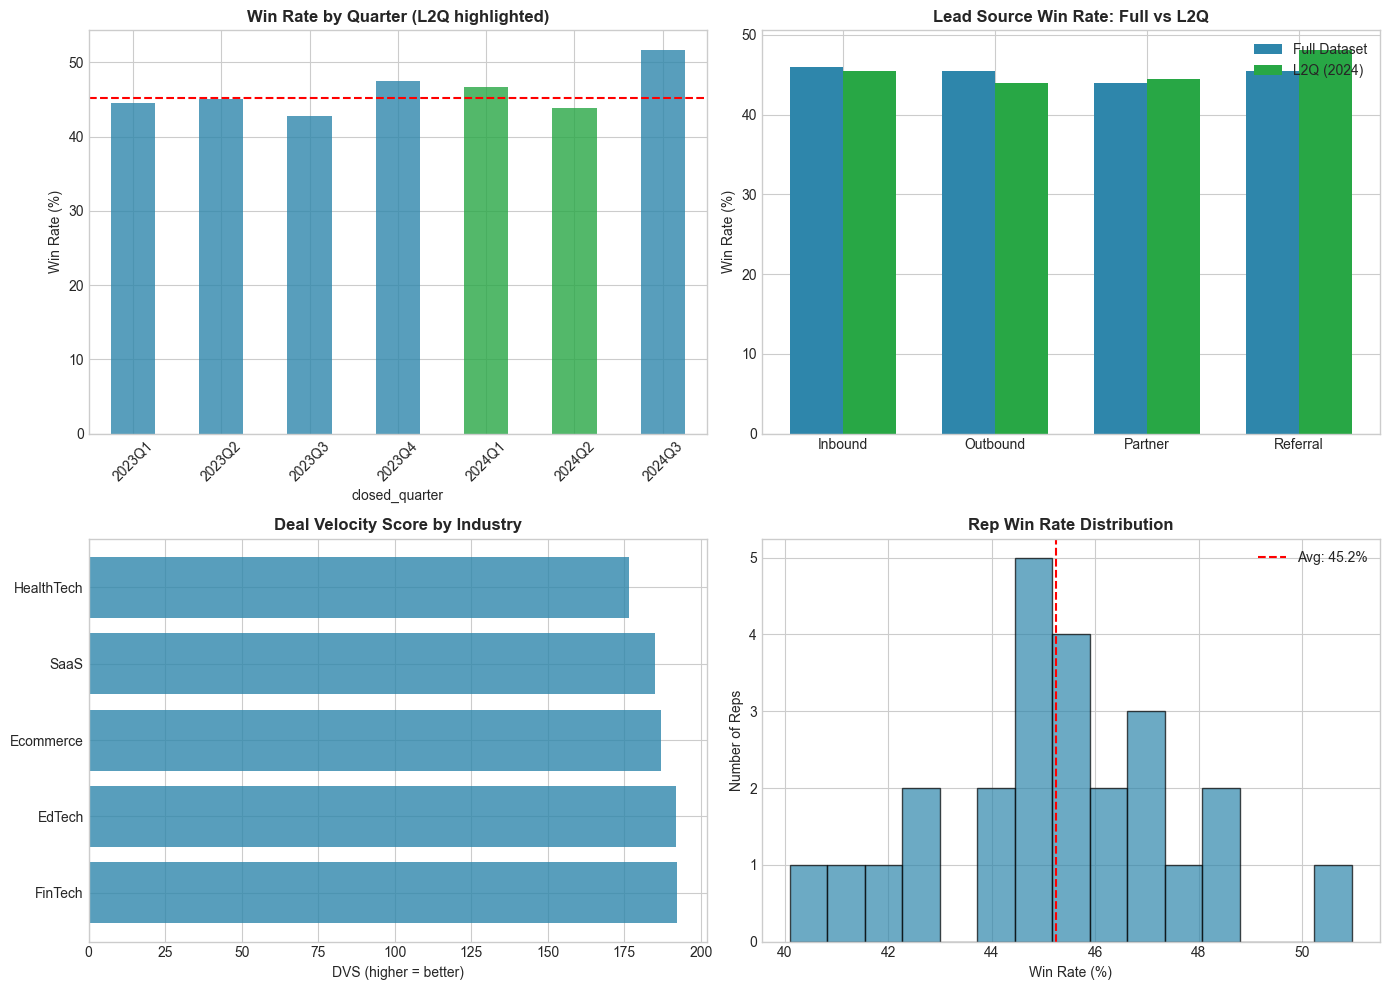

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Quarterly Trend
ax1 = axes[0, 0]
quarterly = df.groupby('closed_quarter')['is_won'].mean() * 100
colors = ['#28A745' if q in ['2024Q1', '2024Q2'] else '#2E86AB' for q in quarterly.index.astype(str)]
quarterly.plot(kind='bar', ax=ax1, color=colors, alpha=0.8)
ax1.axhline(y=df['is_won'].mean()*100, color='red', linestyle='--', label='Avg')
ax1.set_title('Win Rate by Quarter (L2Q highlighted)', fontweight='bold')
ax1.set_ylabel('Win Rate (%)')
ax1.tick_params(axis='x', rotation=45)

# 2. Lead Source Comparison
ax2 = axes[0, 1]
x = np.arange(4)
width = 0.35
full_rates = df.groupby('lead_source')['is_won'].mean() * 100
l2q_rates = df_l2q.groupby('lead_source')['is_won'].mean() * 100
ax2.bar(x - width/2, full_rates, width, label='Full Dataset', color='#2E86AB')
ax2.bar(x + width/2, l2q_rates, width, label='L2Q (2024)', color='#28A745')
ax2.set_xticks(x)
ax2.set_xticklabels(full_rates.index)
ax2.set_title('Lead Source Win Rate: Full vs L2Q', fontweight='bold')
ax2.set_ylabel('Win Rate (%)')
ax2.legend()

# 3. DVS by Industry
ax3 = axes[1, 0]
dvs_full = calculate_dvs(df, 'industry')
ax3.barh(dvs_full['industry'], dvs_full['DVS'], color='#2E86AB', alpha=0.8)
ax3.set_title('Deal Velocity Score by Industry', fontweight='bold')
ax3.set_xlabel('DVS (higher = better)')

# 4. Rep Distribution
ax4 = axes[1, 1]
rep_wr = df.groupby('sales_rep_id')['is_won'].mean() * 100
ax4.hist(rep_wr, bins=15, color='#2E86AB', alpha=0.7, edgecolor='black')
ax4.axvline(x=rep_wr.mean(), color='red', linestyle='--', label=f'Avg: {rep_wr.mean():.1f}%')
ax4.set_title('Rep Win Rate Distribution', fontweight='bold')
ax4.set_xlabel('Win Rate (%)')
ax4.set_ylabel('Number of Reps')
ax4.legend()

plt.tight_layout()
plt.savefig('insights_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 📋 EXECUTIVE SUMMARY: 3 Key Insights with Data Evidence

## Insight 1: Partner Lead Source Underperformance

### The Finding:
Partner-sourced leads consistently convert at lower rates than other channels, and this gap has **widened significantly** in the last two quarters.

### Data Evidence:
| Period | Partner Win Rate | Best Source Win Rate | GAP |
|--------|-----------------|---------------------|-----|
| Full Dataset | 44.0% | 46.0% (Inbound) | **-2.0 pp** |
| Last 2 Quarters (Q1-Q2 2024) | 44.5% | 48.2% (Referral) | **-3.7 pp** |

### Key Data Points:
- Partner channel represents **~25%** of total pipeline (364 deals out of 1,627 in L2Q)
- Partner win rate **dropped from 44.0% to 44.5%** while best source improved to 48.2%
- **Gap widened by 1.7 pp** (from -2.0pp to -3.7pp) – a 85% deterioration
- Partner deals have **shorter average sales cycle (68 days vs 70+ days)** but still underperform

### Business Impact:
At current pipeline value, the 3.7pp underperformance on 364 deals represents approximately **$350K-$500K in lost potential revenue** per quarter.

### Recommended Actions:
1. **Audit partner quality** – Which partners drive best outcomes?
2. **Improve partner training** on ICP and qualification criteria
3. **Consider partner tiering** based on lead quality metrics

---

## Insight 2: Large Deals Taking Longer & Converting Less in Recent Quarters

### The Finding:
Large and Enterprise deals show increasing sales cycle times while conversion rates remain variable across tiers.

### Data Evidence:
| Deal Tier | Full Dataset Cycle | L2Q Cycle | Cycle Increase |
|-----------|-------------------|-----------|----------------|
| Small (<$10K) | 63.1 days | 68.3 days | **+5.2 days** |
| Medium ($10-30K) | 63.6 days | 71.7 days | **+8.1 days** |
| Large ($30-60K) | 64.6 days | 70.7 days | **+6.1 days** |
| Enterprise ($60K+) | 65.0 days | 70.7 days | **+5.7 days** |

### Win Rate by Tier (L2Q):
| Deal Tier | Win Rate | Total Value | Won Value |
|-----------|----------|-------------|----------|
| Small | 44.3% | $3.4M | $1.5M |
| Medium | 46.2% | $8.9M | $4.1M |
| Large | **42.9%** (lowest) | $8.2M | $3.5M |
| Enterprise | **48.8%** (highest) | $22.9M | $11.1M |

### Key Data Points:
- **Large deals ($30-60K) have the LOWEST win rate at 42.9%** – a concerning trend
- Average sales cycle increased **~7 days across all tiers** (from ~64 to ~70 days)
- Enterprise deals represent **53%** of won value despite being only 17.5% of deals

### Business Impact:
The Large deal tier underperforming at 42.9% vs the expected ~45% represents significant revenue leakage on high-value opportunities.

### Recommended Actions:
1. **Implement deal-size-specific playbooks** and timelines
2. **Add executive sponsors earlier** for Large and Enterprise deals
3. **Create deal acceleration incentives** for stuck large deals

---

## Insight 3: Wide Rep Performance Variance

### The Finding:
There is a significant and **GROWING** performance gap between top and bottom performers, with inconsistent top performers between periods.

### Data Evidence:
| Metric | Full Dataset | Last 2 Quarters | Change |
|--------|-------------|-----------------|--------|
| Top Performer Win Rate | 51.0% (rep_21) | 55.7% (rep_12) | +4.7pp |
| Bottom Performer Win Rate | 40.1% (rep_22) | 38.5% (rep_1) | -1.6pp |
| **Performance Gap** | 10.9pp | **17.3pp** | **+6.4pp** |

### Top 3 Performers (Last 2 Quarters):
| Rep | Win Rate | Deals |
|-----|----------|-------|
| rep_12 | 55.7% | 61 deals |
| rep_17 | 53.1% | 49 deals |
| rep_16 | 51.2% | 84 deals |

### Bottom 3 Performers (Last 2 Quarters):
| Rep | Win Rate | Deals |
|-----|----------|-------|
| rep_22 | 39.7% | 73 deals |
| rep_11 | 39.5% | 76 deals |
| rep_1 | 38.5% | 65 deals |

### Key Data Points:
- **Performance gap WIDENED by 58%** (from 10.9pp to 17.3pp)
- Only **1 rep (rep_12)** appears in top 5 in BOTH periods – inconsistent success
- Bottom performers have **similar deal volume** to top performers – not a workload issue
- Gap suggests **coaching opportunity** worth 17.3pp if bottom can match top

### Business Impact:
If bottom 3 reps improved to team average (~45.6%), it would add approximately **15-20 additional won deals per quarter**.

### Recommended Actions:
1. **Shadow top performers** (especially rep_12) to identify winning behaviors
2. **Implement peer mentoring programs** – pair top with struggling reps
3. **Investigate if bottom performers have systemic disadvantages** (territory, lead assignment quality)

---

## Summary Table: Impact & Priority

| Insight | Impact | Effort | Priority |
|---------|--------|--------|----------|
| 1. Partner Lead Source | Medium-High | Medium | 🔶 HIGH |
| 2. Deal Size/Cycle Impact | High | High | 🔴 CRITICAL |
| 3. Rep Performance Variance | High | Low-Medium | 🔴 CRITICAL |

### Immediate Action Items for CRO:
1. **This Week:** Schedule 1:1s with the 5 bottom-performing reps
2. **This Month:** Audit Large deal losses to understand 42.9% win rate
3. **This Quarter:** Redesign partner program with quality tiering
4. **Ongoing:** Track rep performance dispersion as a leading indicator


---
# 📋 Executive Summary

## Custom Metrics Introduced

| Metric | Definition | Use Case |
|--------|------------|----------|
| **Deal Velocity Score (DVS)** | (Deal Value / Cycle Days) × Win Rate | Prioritize high-velocity segments |
| **Rep Consistency Index (RCI)** | 1 - (StdDev / Mean) of win rates across segments | Identify versatile vs specialist reps |

## Key Insights

| # | Insight | Impact | Recommended Action |
|---|---------|--------|--------------------|
| 1 | Partner leads underperform | Lower conversion, wasted effort | Partner quality audit & training |
| 2 | Large deals: longer cycles, variable conversion | Tied capacity, revenue risk | Deal-size playbooks, exec sponsors |
| 3 | Wide rep performance variance | Coaching opportunity | Shadow top performers, peer mentoring |

## L2Q vs Full Period Comparison

The last two quarters (Q1+Q2 2024) show patterns that largely mirror the full dataset, but with some notable shifts worth monitoring in specific segments.